EXPLORATORY DATA ANALYSIS

Roles to Explore :

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Filter for India Data Analyst roles

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# India jobs only
df_IND = df[df['job_country'] == 'India'].copy()

In [5]:
# Remove bad values
df_IND = df_IND[(~df_IND['job_location'].isin(['India', 'Anywhere'])) & (df_IND['job_location'].notna())]

In [6]:
# Remove bad values
df_IND = df_IND[(~df_IND['job_location'].isin(['India', 'Anywhere']))& (df_IND['job_location'].notna())]

# Top locations
location_counts = (df_IND['job_location'].value_counts().head(7).reset_index())

location_counts.columns = ['job_location', 'count']


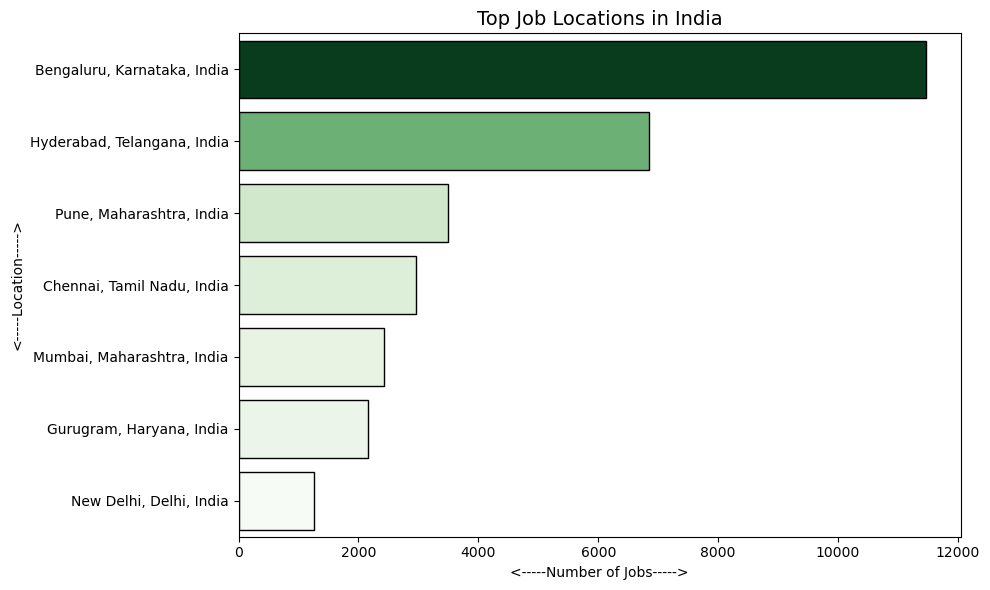

In [7]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=location_counts,
    x='count',
    y='job_location',
    hue='count',
    palette='Greens',
    legend=False,
    edgecolor='black',
    linewidth=1
)

plt.title('Top Job Locations in India', fontsize=14)
plt.xlabel('<-----Number of Jobs----->')
plt.ylabel('<-----Location----->')

plt.tight_layout()
plt.show()

In [8]:
df_IND

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
16,Data Engineer,Big Data Engineer,"Pune, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-06-15 13:28:03,False,False,India,None,NaN,NaN,Hexaware Technologies,"[powershell, python, sql, mysql, sql server, d...","{'cloud': ['databricks', 'azure'], 'databases'..."
19,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,None,NaN,NaN,Bitwise Solutions,"[r, sql, python, scala, java, c++, hadoop, tab...","{'analyst_tools': ['tableau'], 'libraries': ['..."
29,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Exusia,Full-time,False,India,2023-03-26 13:16:20,False,False,India,None,NaN,NaN,Exusia,None,None
42,Senior Data Engineer,"Senior Data Engineer(Python)-1563,1637&1633","Chennai, Tamil Nadu, India",via HR Software For Growing Businesses | Fresh...,Full-time,False,India,2023-11-10 13:30:41,True,False,India,None,NaN,NaN,CESIT,"[python, sql, aws, pyspark, docker, jira]","{'async': ['jira'], 'cloud': ['aws'], 'librari..."
80,Data Engineer,Director - Enterprise Architecture and Data En...,"Chennai, Tamil Nadu, India",via Indeed,Full-time,False,India,2023-05-11 13:20:16,False,False,India,None,NaN,NaN,Ford Motor Company,"[gcp, graphql, kubernetes]","{'cloud': ['gcp'], 'libraries': ['graphql'], '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785674,Data Scientist,Data Scientist,"Kolkata, West Bengal, India",via LinkedIn,Full-time,False,India,2023-01-12 06:12:32,False,False,India,None,NaN,NaN,One Billion Ideas Pvt. LTD.,"[r, python, sql, scala, java, c++, matplotlib,...","{'analyst_tools': ['tableau'], 'libraries': ['..."
785684,Data Engineer,Data Engineer,"Noida, Uttar Pradesh, India",via LinkedIn,Full-time,False,India,2023-01-11 06:28:41,False,False,India,None,NaN,NaN,Deuglo Infosystem Private Limited,"[sql, shell, python, aws]","{'cloud': ['aws'], 'programming': ['sql', 'she..."
785691,Data Analyst,Business Intelligence Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-23 06:12:09,False,False,India,None,NaN,NaN,Mobile Programming LLC,"[sql, python, shell, sql server, tableau, micr...","{'analyst_tools': ['tableau', 'microstrategy']..."
785695,Data Engineer,AWS Data Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-05 06:35:07,False,False,India,None,NaN,NaN,LatentView Analytics,"[python, sql, scala, aws, snowflake, databrick...","{'cloud': ['aws', 'snowflake', 'databricks'], ..."


In [9]:
print(df_IND[['job_work_from_home',
              'job_no_degree_mention',
              'job_health_insurance']].sum())

print(df_IND[['job_work_from_home',
              'job_no_degree_mention',
              'job_health_insurance']].shape)

job_work_from_home          0
job_no_degree_mention    9474
job_health_insurance        1
dtype: int64
(37714, 3)


In [10]:
for col in ['job_work_from_home',
            'job_no_degree_mention',
            'job_health_insurance']:
    print(f'\n{col}')
    print(df_IND[col].value_counts())


job_work_from_home
job_work_from_home
False    37714
Name: count, dtype: int64

job_no_degree_mention
job_no_degree_mention
False    28240
True      9474
Name: count, dtype: int64

job_health_insurance
job_health_insurance
False    37713
True         1
Name: count, dtype: int64


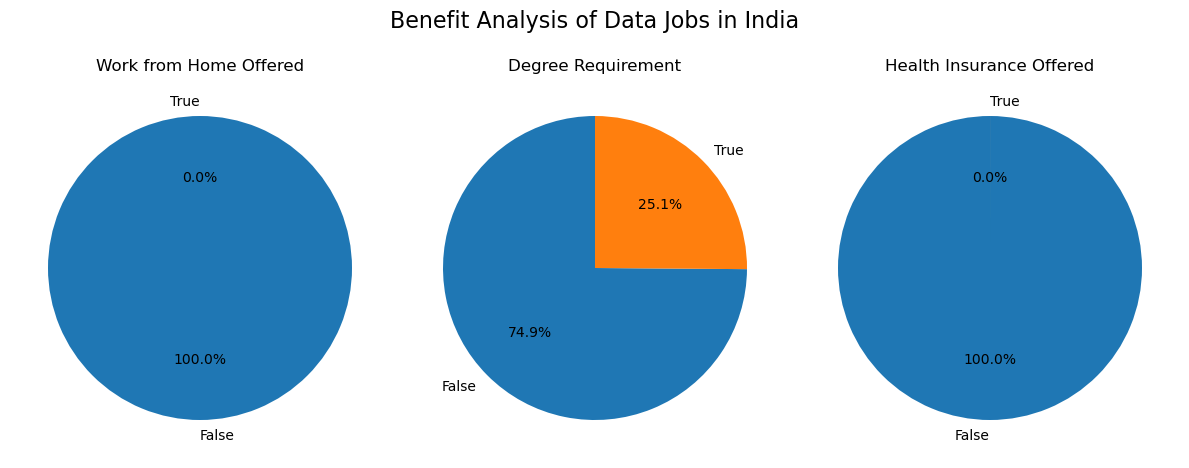

In [11]:
import matplotlib.pyplot as plt

dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

for i, (column, title) in enumerate(dict_column.items()):

    counts = (
        df_IND[column]
        .value_counts()
        .reindex([False, True], fill_value=0)
    )

    ax[i].pie(
        counts.values,
        labels=['False', 'True'],
        autopct='%1.1f%%',
        startangle=90
    )

    ax[i].set_title(title)

plt.suptitle('Benefit Analysis of Data Jobs in India', fontsize=16)
plt.tight_layout()
plt.show()

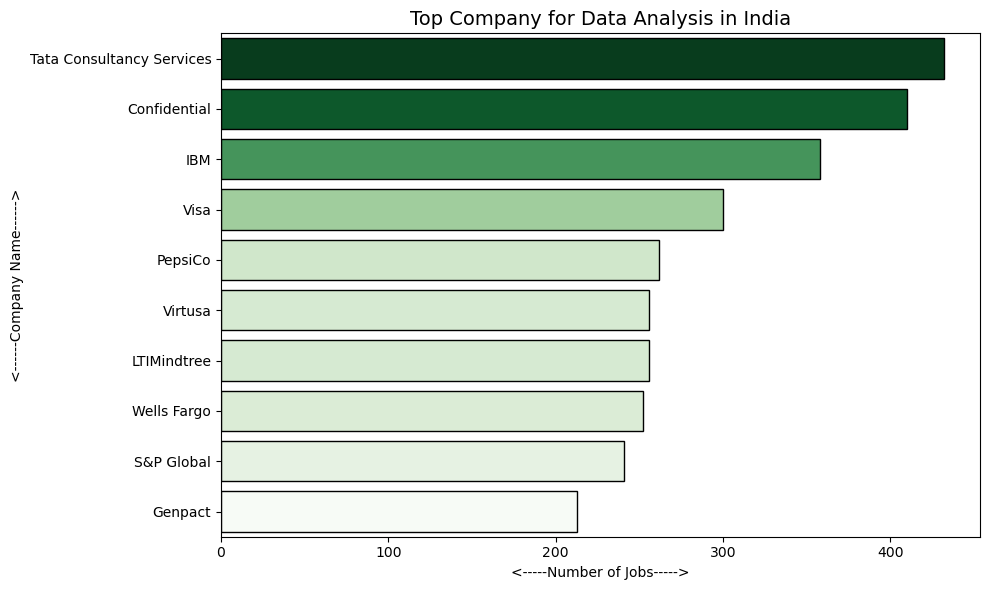

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# India jobs only
df_IND = df[df['job_country'] == 'India'].copy()

# Remove bad values
df_IND = df_IND[
    (~df_IND['company_name'].isin(['India', 'Anywhere']))
    & (df_IND['company_name'].notna())
]

# Top locations
location_counts = (
    df_IND['company_name']
    .value_counts()
    .head(10)
    .reset_index()
)

location_counts.columns = ['company_name', 'count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=location_counts,
    x='count',
    y='company_name',
    hue='count',
    palette='Greens',
    legend=False,
    edgecolor='black',
    linewidth=1
)

plt.title('Top Company for Data Analysis in India', fontsize=14)
plt.xlabel('<-----Number of Jobs----->')
plt.ylabel('<------Company Name------>')

plt.tight_layout()
plt.show()